# Lab 9: Text Clustering Using K-Means
Course: BAM-3034 – Sentiment Analysis & Text Mining

This lab demonstrates text clustering using K-Means and evaluation using Elbow, Silhouette, and CH score.

## Objectives
- Preprocess text data
- Convert text using TF-IDF
- Apply K-Means clustering
- Evaluate clusters using multiple metrics

## Step 1: Import Libraries

In [11]:
import pandas as pd
import numpy as np
import nltk
import string
import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hitham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Step 2: Load Dataset

In [12]:
data = [
"The movie was fantastic and very entertaining.",
"Terrible customer service, I am so disappointed.",
"Amazing quality and excellent value for money.",
"Worst product ever! Do not buy it.",
"The film was a masterpiece; truly a great watch.",
"I had the worst experience with this company.",
"The book was incredibly engaging and well-written.",
"Completely dissatisfied with the service provided."
]

df = pd.DataFrame(data, columns=["text"])
df

,text
0,The movie was fantastic and very entertaining.
1,"Terrible customer service, I am so disappointed."
2,Amazing quality and excellent value for money.
3,Worst product ever! Do not buy it.
4,The film was a masterpiece; truly a great watch.
5,I had the worst experience with this company.
6,The book was incredibly engaging and well-writ...
7,Completely dissatisfied with the service provi...


## Step 3: Preprocess Text

In [13]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['clean_text'] = df['text'].apply(preprocess_text)
df

,text,clean_text
0,The movie was fantastic and very entertaining.,movie fantastic entertaining
1,"Terrible customer service, I am so disappointed.",terrible customer service disappointed
2,Amazing quality and excellent value for money.,amazing quality excellent value money
3,Worst product ever! Do not buy it.,worst product ever buy
4,The film was a masterpiece; truly a great watch.,film masterpiece truly great watch
5,I had the worst experience with this company.,worst experience company
6,The book was incredibly engaging and well-writ...,book incredibly engaging wellwritten
7,Completely dissatisfied with the service provi...,completely dissatisfied service provided


## Step 4: TF-IDF

In [14]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])
X.shape

(8, 30)

## Step 5: K-Means

In [15]:
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(X)
df

,text,clean_text,cluster
0,The movie was fantastic and very entertaining.,movie fantastic entertaining,1
1,"Terrible customer service, I am so disappointed.",terrible customer service disappointed,1
2,Amazing quality and excellent value for money.,amazing quality excellent value money,0
3,Worst product ever! Do not buy it.,worst product ever buy,1
4,The film was a masterpiece; truly a great watch.,film masterpiece truly great watch,1
5,I had the worst experience with this company.,worst experience company,1
6,The book was incredibly engaging and well-writ...,book incredibly engaging wellwritten,1
7,Completely dissatisfied with the service provi...,completely dissatisfied service provided,1


## Step 6: Inspect Clusters

In [16]:
for i in range(2):
    print(f"\nCluster {i}:")
    print(df[df['cluster'] == i]['text'].values)


Cluster 0:
['Amazing quality and excellent value for money.']

Cluster 1:
['The movie was fantastic and very entertaining.'
 'Terrible customer service, I am so disappointed.'
 'Worst product ever! Do not buy it.'
 'The film was a masterpiece; truly a great watch.'
 'I had the worst experience with this company.'
 'The book was incredibly engaging and well-written.'
 'Completely dissatisfied with the service provided.']


In [17]:
def top_terms_per_cluster(kmeans, vectorizer, n_terms=5):
    terms = vectorizer.get_feature_names_out()
    for i, center in enumerate(kmeans.cluster_centers_):
        print(f"\nCluster {i} top terms:")
        top_indices = center.argsort()[-n_terms:]
        print([terms[j] for j in top_indices])

top_terms_per_cluster(kmeans, vectorizer)


Cluster 0 top terms:
['amazing', 'excellent', 'money', 'quality', 'value']

Cluster 1 top terms:
['movie', 'experience', 'company', 'service', 'worst']


## Step 7: Elbow Method

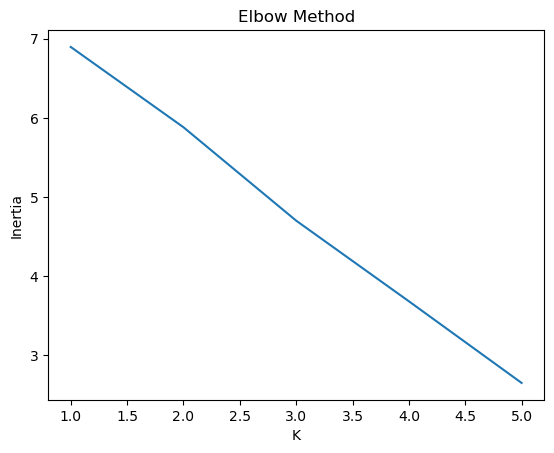

In [18]:
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 6)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(k_range, inertia)
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Because our dataset is very small, the inertia curve does not show a sharp elbow.
This is normal. In practice, the Elbow Method works best with larger datasets



## Silhouette Score & Calinski–Harabasz Index

### **Silhouette Score**
The Silhouette Score measures how well each data point fits within its assigned cluster compared to other clusters. It considers both:

- **Cohesion** — how close a point is to other points in the same cluster  
- **Separation** — how far it is from points in other clusters  

The score ranges from **–1 to +1**:

- **+1** → Points are well‑matched to their cluster and far from others  
- **0** → Clusters overlap or are poorly defined  
- **Negative** → Points may be assigned to the wrong cluster  

Silhouette works best when clusters are well‑separated and the dataset is large enough to form meaningful structure. With very small datasets (like ours), scores often remain close to zero.

---

### **Calinski–Harabasz (CH) Index**
The Calinski–Harabasz Index evaluates clustering by comparing:

- **Between‑cluster dispersion** (how far clusters are from each other)  
- **Within‑cluster dispersion** (how compact each cluster is)  

The formula is essentially:

$\text{CH} = \frac{\text{Between-cluster variance}}{\text{Within-cluster variance}}$

Higher values indicate:

- Well‑separated clusters  
- Compact clusters  
- Better-defined structure  

However, CH scores become less meaningful when:

- The dataset is very small  
- Clusters contain only a few points  
- TF‑IDF vectors are sparse  

This is why CH values in our experiment remain low and change only slightly as \(K\) increases.



## Step 8: Silhouette Score

In [19]:
sil = silhouette_score(X, df['cluster'])
print("Silhouette Score:", sil)

Silhouette Score: 0.009076052258813725


## Step 9: Calinski-Harabasz Index

In [20]:
ch = calinski_harabasz_score(X.toarray(), df['cluster'])
print("CH Score:", ch)

CH Score: 1.0349997574254326


## Step 10: Compare Different K

In [21]:
k_range = range(2, 6)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)

    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X.toarray(), labels)

    print(f"K={k} | Silhouette={sil:.3f} | CH={ch:.2f}")

K=2 | Silhouette=0.009 | CH=1.03
K=3 | Silhouette=0.036 | CH=1.17
K=4 | Silhouette=0.038 | CH=1.16
K=5 | Silhouette=0.042 | CH=1.20


##  Reflection
- What is the best K?
- Do clusters make sense?
- How does preprocessing affect results?

# In your Lab9 assignment,
- you will need Implement Hierarchical Clustering (with different linkage methods), 
- and then DBSCAN, and abserve how it Assigns cluster labels and observe how DBSCAN handles outliers.
- Compare the clustering results of the three algorithms in terms of cluster quality, handling of outliers, and computational efficiency.

# Discuss Results
1. Analyze the advantages and limitations of each algorithm based on:
- Cluster quality.
- Handling noise and outliers.
- Scalability to larger datasets.
2. Identify the most suitable algorithm for your dataset